# 1. 기본 전처리

In [ ]:
!pip install -U ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.3 MB/s eta 0:00:00


In [ ]:
#데이터 불러오기
import pandas as pd
from ydata_profiling import ProfileReport
data = pd.read_csv('/content/dataset.csv')

/tmp/ipykernel_2475/2785852706.py:3: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [ ]:
# 타깃 피처 만들기
df = data[data['isOpen'] == 0].copy() # isOpen == 1인 경우 아직 거래가 완전히 끝나지 않은 불완전한 데이터이기 때문에 clear_date 값이 존재하지 않음
df['clear_date'] = pd.to_datetime(df['clear_date'], errors = 'coerce')
df['due_in_date'] = pd.to_datetime(df['due_in_date'].astype(int).astype(str),format='%Y%m%d' ,errors = 'coerce')
df['target'] = (df['clear_date'] > df['due_in_date']).astype(int)

In [ ]:
# 중복 행 제거
before_rows = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed duplicate rows: {before_rows - len(df):,}")
print(f"Remaining rows: {len(df):,}")

Removed duplicate rows: 842
Remaining rows: 39,158


In [ ]:
# 학습 데이터, 테스트 데이터 나누기
df = df.sort_values('baseline_create_date').reset_index(drop=True) # 과거의 학습 데이터로 미래의 데이터를 분류해야하기 때문에 시간 순서로 정렬
split_idx = int(len(df) * 0.8) # train : test = 8 : 2로 분리
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

In [ ]:
# 학습 데이터, 테스트 데이터 다운로드
train_df.to_csv("/content/train.csv", index=False)
test_df.to_csv("/content/test.csv", index=False)

In [ ]:
# 기초 EDA 정보 다운로드
report = ProfileReport(train_df)
report.to_file("/content/data_report.html")

/usr/local/lib/python3.12/dist-packages/ydata_profiling/utils/dataframe.py:137: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={"index": "df_index"}, inplace=True)


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 20/20 [00:03<00:00,  6.43it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

# 2. 베이스라인 모델링


In [ ]:
import pandas as pd
import numpy as np
train = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test.csv')

In [ ]:
# 연체일을 나타내는 delay_days 피처 생성
train['clear_date'] = pd.to_datetime(train['clear_date'])
train['due_in_date'] = pd.to_datetime(train['due_in_date'])
train['delay_days'] = (train['clear_date'] - train['due_in_date']).dt.days

test['clear_date'] = pd.to_datetime(test['clear_date'])
test['due_in_date'] = pd.to_datetime(test['due_in_date'])
test['delay_days'] = (test['clear_date'] - test['due_in_date']).dt.days

In [ ]:
bins = [-float('inf'), 0, 5, 15, float('inf')]
labels = ['on_time_or_early', '1_5', '6_15', '16_plus']

# 4개의 클래스로 타깃 피처 생성(정상, 1-5일 지연, 6-15일 지연, 16이상 지연)
train['delay_class'] = pd.cut(train['delay_days'], bins=bins, labels=labels)
train['delay_class'].value_counts(dropna=False)
train['delay_class'].value_counts(normalize=True, dropna=False) * 100

test['delay_class'] = pd.cut(test['delay_days'], bins=bins, labels=labels)
test['delay_class'].value_counts(dropna=False)
test['delay_class'].value_counts(normalize=True, dropna=False) * 100

,proportion
delay_class,
on_time_or_early,60.546476
1_5,31.703269
6_15,4.992339
16_plus,2.757916


In [ ]:
# 기존 이진 분류 타깃(target)은 별도로 보존
binary_train_y = train['target'].copy()
binary_test_y = test['target'].copy()

# 타깃 피처와 직접적으로 연관되어있거나(clear_date, delay_days) 아무런 정보도 없는 열(posting_id, isOpen, business_year, area_business), 단순 식별자(doc_id, invoice_id), ,현재는 사용하기 힘든 열들(cust_number, name_customer, 날짜관련 변수들)
drop_cols = ['target', 'clear_date', 'delay_days', 'posting_id', 'isOpen','buisness_year','area_business','doc_id', 'invoice_id', 'document_create_date', 'document_create_date.1', 'due_in_date', 'baseline_create_date','posting_date', 'cust_number', 'name_customer']
train.drop(columns=drop_cols, axis=1, inplace=True)
test.drop(columns=drop_cols, axis=1, inplace=True)

In [ ]:
train = train.dropna().copy()
test = test.dropna().copy()

# dropna 이후 남은 행과 이진 타깃 인덱스 정렬
binary_train_y = binary_train_y.loc[train.index]
binary_test_y = binary_test_y.loc[test.index]

In [ ]:
from sklearn.preprocessing import OneHotEncoder
# 타깃 피처 분리
train_y = train['delay_class'].copy()
train_x = train.drop(columns='delay_class', axis=1)
test_y = test['delay_class'].copy()
test_x = test.drop(columns='delay_class', axis=1)

#원핫 인코딩
cat_cols = train_x.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = train_x.select_dtypes(exclude=['object', 'category']).columns.tolist()
ohe = OneHotEncoder(handle_unknown='ignore',sparse_output=False)
train_cat = ohe.fit_transform(train_x[cat_cols])
test_cat = ohe.transform(test_x[cat_cols])

train_cat_df = pd.DataFrame(
    train_cat,
    columns=ohe.get_feature_names_out(cat_cols),
    index=train_x.index
)

test_cat_df = pd.DataFrame(
    test_cat,
    columns=ohe.get_feature_names_out(cat_cols),
    index=test_x.index
)

train_x = pd.concat([train_x[num_cols], train_cat_df], axis=1)
test_x = pd.concat([test_x[num_cols], test_cat_df], axis=1)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
lr = LogisticRegression(
    max_iter=5000,
    random_state=42,
    class_weight='balanced'
)

lr.fit(train_x, train_y)
pred = lr.predict(test_x)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
labels = ['on_time_or_early', '1_5', '6_15', '16_plus']
print('accuracy:', accuracy_score(test_y, pred))
print('-------------')
print('macro f1:', f1_score(test_y, pred, average='macro'))
print('-------------')
print(classification_report(test_y, pred, labels = labels))
print('-------------')
print(confusion_matrix(test_y, pred, labels=labels))

accuracy: 0.5430286006128703
-------------
macro f1: 0.476769632176148
-------------
                  precision    recall  f1-score   support

on_time_or_early       0.78      0.53      0.63      4742
             1_5       0.41      0.58      0.48      2483
            6_15       0.21      0.45      0.29       391
         16_plus       0.48      0.54      0.51       216

        accuracy                           0.54      7832
       macro avg       0.47      0.53      0.48      7832
    weighted avg       0.62      0.54      0.56      7832

-------------
[[2518 1901  257   66]
 [ 671 1442  338   32]
 [  44  140  176   31]
 [  10   34   55  117]]


## 이진 분류 베이스라인

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
# 기존 target 피처(0/1)를 사용하는 이진 분류 로지스틱 회귀
binary_lr = LogisticRegression(
    max_iter=5000,
    random_state=42,
    class_weight='balanced'
)

binary_lr.fit(train_x, binary_train_y)
binary_pred = binary_lr.predict(test_x)

In [ ]:
binary_labels = [0, 1]
print('accuracy:', accuracy_score(binary_test_y, binary_pred))
print('-------------')
print('macro f1:', f1_score(binary_test_y, binary_pred, average='macro'))
print('-------------')
print(classification_report(binary_test_y, binary_pred, labels=binary_labels))
print('-------------')
print(confusion_matrix(binary_test_y, binary_pred, labels=binary_labels))

accuracy: 0.6280643513789581
-------------
macro f1: 0.6275430775352782
-------------
              precision    recall  f1-score   support

           0       0.77      0.55      0.64      4742
           1       0.52      0.75      0.61      3090

    accuracy                           0.63      7832
   macro avg       0.65      0.65      0.63      7832
weighted avg       0.67      0.63      0.63      7832

-------------
[[2606 2136]
 [ 777 2313]]


# 3. 데이터 클랜징


In [ ]:
import pandas as pd
import numpy as np
train = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test.csv')

In [ ]:
# 캐나다 달러와 US 달러 통일
train['amount_in_usd'] = train.apply(lambda row: row['total_open_amount'] * 0.75 if row['invoice_currency'] == 'CAD' else row['total_open_amount'], axis=1)
test['amount_in_usd'] = test.apply(lambda row: row['total_open_amount'] * 0.75 if row['invoice_currency'] == 'CAD' else row['total_open_amount'], axis=1)

In [ ]:
#total_open_amount의 분포가 매우 치우쳐져 있기 때문에, 로그 변환을 통해 분포 완화
train['amount_in_usd'] = np.log1p(train['amount_in_usd'])
test['amount_in_usd'] = np.log1p(test['amount_in_usd'])

In [ ]:
# 결제 수단의 등장 횟수가 30회 이하인 경우 Other 클래스로 변환
counts = train["cust_payment_terms"].value_counts()
train["cust_payment_terms_grp"] = train["cust_payment_terms"].where(
    train["cust_payment_terms"].map(counts) > 30,
    "Other"
)
test["cust_payment_terms_grp"] = test["cust_payment_terms"].where(
    test["cust_payment_terms"].map(counts) > 30,
    "Other"
)

In [ ]:
# 송장이 생성된 기준 날짜의 월, 일, 요일 추출
train['baseline_create_date'] = pd.to_datetime(train['baseline_create_date'], format='%Y%m%d', errors='coerce')
test['baseline_create_date'] = pd.to_datetime(test['baseline_create_date'], format='%Y%m%d', errors='coerce')

train['baseline_month'] = train['baseline_create_date'].dt.month
train['baseline_day'] = train['baseline_create_date'].dt.day
train['baseline_dayofweek'] = train['baseline_create_date'].dt.dayofweek
test['baseline_month'] = test['baseline_create_date'].dt.month
test['baseline_day'] = test['baseline_create_date'].dt.day
test['baseline_dayofweek'] = test['baseline_create_date'].dt.dayofweek


In [ ]:
# 송장 생성일과 마감일 사이의 기간 추가
train['due_in_date'] = pd.to_datetime(train['due_in_date'], errors='coerce')
test['due_in_date'] = pd.to_datetime(test['due_in_date'], errors='coerce')
train['Allowed_Pay_Days'] = (train['due_in_date'] - train['baseline_create_date']).dt.days
test['Allowed_Pay_Days'] = (test['due_in_date'] - test['baseline_create_date']).dt.days

In [ ]:
# cust_number 자릿수 맞추기
def clean_cust_number(df):
    df = df.copy()

    cust_number_stripped = df["cust_number"].astype(str).str.strip()
    is_9_digit = cust_number_stripped.str.fullmatch(r"\d{9}")

    df["cust_number"] = cust_number_stripped.where(
        ~is_9_digit,
        cust_number_stripped.str.zfill(10)
    )

    return df

train = clean_cust_number(train)
test = clean_cust_number(test)

In [ ]:
drop_cols = ['doc_id', 'invoice_currency', 'document type', 'area_business', 'isOpen', 'invoice_id','document_create_date', 'document_create_date.1', 'posting_date', 'total_open_amount']
train.drop(columns = drop_cols, inplace=True)
test.drop(columns = drop_cols, inplace=True)


In [ ]:
train.to_csv('/content/train_cleaned.csv', index=False)
test.to_csv('/content/test_cleaned.csv', index=False)

In [ ]:
train

,business_code,cust_number,name_customer,clear_date,buisness_year,due_in_date,posting_id,baseline_create_date,cust_payment_terms,target,amount_in_usd,cust_payment_terms_grp,baseline_month,baseline_day,baseline_dayofweek,Allowed_Pay_Days
0,CA02,0140104249,SOB associates,2019-01-23,2019.0,2018-12-24,1.0,2018-12-14,CA10,1,11.663576,CA10,12,14,4,10
1,U001,0200706844,WINC co,2019-02-19,2019.0,2018-12-29,1.0,2018-12-14,NAA8,1,6.359366,NAA8,12,14,4,15
2,U001,0200726979,BJ'S corp,2019-01-15,2019.0,2019-01-14,1.0,2018-12-30,NAA8,1,4.080584,NAA8,12,30,6,15
3,U001,0200706844,WINC systems,2019-01-15,2019.0,2019-01-14,1.0,2018-12-30,NAA8,1,10.962005,NAA8,12,30,6,15
4,U001,0200794332,COST foundation,2019-01-23,2019.0,2019-01-14,1.0,2018-12-30,NAAX,1,8.992506,NAAX,12,30,6,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31321,U001,0200788848,DAIRY trust,2019-11-27,2019.0,2019-12-03,1.0,2019-11-18,NAA8,0,10.639189,NAA8,11,18,0,15
31322,CA02,0140104249,SOB systems,2019-12-02,2019.0,2019-11-28,1.0,2019-11-18,CA10,1,10.771515,CA10,11,18,0,10
31323,U001,0200779051,AFFILI systems,2019-11-27,2019.0,2019-12-03,1.0,2019-11-18,NAA8,0,11.896931,NAA8,11,18,0,15
31324,U001,0200772670,ASSOCIAT co,2019-12-04,2019.0,2019-12-03,1.0,2019-11-18,NAU5,1,8.570087,NAU5,11,18,0,15


# 4. 통합 EDA

## 피처 엔지니어링 EDA

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT
TRAIN_PATH = DATA_DIR / "train_cleaned.csv"
TEST_PATH = DATA_DIR / "test_cleaned.csv"
TRAIN_OUT = DATA_DIR / "train_eda_revised.csv"
TEST_OUT = DATA_DIR / "test_eda_revised.csv"
MACRO_QUARTER_PATH = DATA_DIR / "macro_variable.csv"
MACRO_MARKET_PATH = DATA_DIR / "market_macro_monthly.csv"

DATE_COLS = ["baseline_create_date", "due_in_date", "clear_date"]
TEXT_DTYPES = {
    "cust_number": "string",
    "business_code": "string",
    "name_customer": "string",
    "cust_payment_terms": "string",
    "cust_payment_terms_grp": "string",
}

LATE_BUSINESS_DAYS = 5
# [기존 코드 - 주석처리] N_RECENT = 5
RECENT_HISTORY_WINDOWS = [5, 10, 20]
TIME_DECAY_LAMBDA = 0.8

## 데이터 로드

In [ ]:
def load_invoice_data(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, dtype=TEXT_DTYPES)
    if "target" in df.columns:
        df = df.rename(columns={"target": "target_old"})

    # 날짜 컬럼은 이후 영업일 계산에 바로 쓸 수 있게 변환한다.
    for col in DATE_COLS:
        df[col] = pd.to_datetime(df[col], errors="coerce")

    return df


train_eda_revised = load_invoice_data(TRAIN_PATH)
test_eda_revised = load_invoice_data(TEST_PATH)

for name, df in [("train", train_eda_revised), ("test", test_eda_revised)]:
    print(f"{name}: rows={len(df):,}, cols={len(df.columns)}, customers={df['cust_number'].nunique():,}")
    display(df.head(3))

train: rows=31,326, cols=16, customers=982


,business_code,cust_number,name_customer,clear_date,buisness_year,due_in_date,posting_id,baseline_create_date,cust_payment_terms,target_old,amount_in_usd,cust_payment_terms_grp,baseline_month,baseline_day,baseline_dayofweek,Allowed_Pay_Days
0,CA02,0140104249,SOB associates,2019-01-23,2019.0,2018-12-24,1.0,2018-12-14,CA10,1,11.663576,CA10,12,14,4,10
1,U001,0200706844,WINC co,2019-02-19,2019.0,2018-12-29,1.0,2018-12-14,NAA8,1,6.359366,NAA8,12,14,4,15
2,U001,0200726979,BJ'S corp,2019-01-15,2019.0,2019-01-14,1.0,2018-12-30,NAA8,1,4.080584,NAA8,12,30,6,15


test: rows=7,832, cols=16, customers=582


,business_code,cust_number,name_customer,clear_date,buisness_year,due_in_date,posting_id,baseline_create_date,cust_payment_terms,target_old,amount_in_usd,cust_payment_terms_grp,baseline_month,baseline_day,baseline_dayofweek,Allowed_Pay_Days
0,CA02,0140106408,WAL-M foundation,2019-12-05,2019.0,2019-11-28,1.0,2019-11-18,CA10,1,10.817586,CA10,11,18,0,10
1,U001,0200718130,SYSCO F trust,2019-12-23,2019.0,2019-12-20,1.0,2019-11-18,NA32,1,10.121198,NA32,11,18,0,32
2,U001,0200755701,ASSOCI foundation,2019-12-04,2019.0,2019-12-03,1.0,2019-11-18,NAA8,1,11.586048,NAA8,11,18,0,15


## 기본 피쳐 생성

In [ ]:
def business_days_between(start_dates, end_dates) -> pd.Series:
    start_dates = pd.to_datetime(start_dates, errors="coerce")
    if not isinstance(end_dates, pd.Series):
        end_dates = pd.Series(end_dates, index=start_dates.index)
    end_dates = pd.to_datetime(end_dates, errors="coerce")

    result = pd.Series(np.nan, index=start_dates.index, dtype="float")
    valid = start_dates.notna() & end_dates.notna()
    if valid.any():
        start_np = start_dates.loc[valid].values.astype("datetime64[D]")
        end_np = end_dates.loc[valid].values.astype("datetime64[D]")
        result.loc[valid] = np.busday_count(start_np, end_np)
    return result


def add_business_days_late(df: pd.DataFrame) -> None:
    # 주말을 제외한 실제 지연일을 계산한다.
    df["business_days_late"] = business_days_between(df["due_in_date"], df["clear_date"]).astype(int)


def add_basic_features(train_df: pd.DataFrame, test_df: pd.DataFrame) -> np.ndarray:
    for df in [train_df, test_df]:
        add_business_days_late(df)
        df["target"] = (df["business_days_late"] > LATE_BUSINESS_DAYS).astype(int)
        df["due_weekend_flag"] = df["due_in_date"].dt.weekday.isin([5, 6]).astype(int)

    # 금액 구간은 train 기준으로 만들고 test에는 같은 경계를 적용한다.
    _, raw_bins = pd.qcut(train_df["amount_in_usd"], q=4, labels=False, retbins=True, duplicates="drop")
    amount_bins = np.r_[-np.inf, raw_bins[1:-1], np.inf]
    amount_labels = list(range(len(amount_bins) - 1))

    for df in [train_df, test_df]:
        df["amount_bin"] = pd.cut(
            df["amount_in_usd"],
            bins=amount_bins,
            labels=amount_labels,
            include_lowest=True,
        ).astype("int64")

    return amount_bins


amount_bins = add_basic_features(train_eda_revised, test_eda_revised)
print("Amount bin edges:", amount_bins)
print(pd.DataFrame({
    "train_target_old": train_eda_revised["target_old"].value_counts().sort_index(),
    "train_target": train_eda_revised["target"].value_counts().sort_index(),
    "test_target_old": test_eda_revised["target_old"].value_counts().sort_index(),
    "test_target": test_eda_revised["target"].value_counts().sort_index(),
}).fillna(0).astype(int))

Amount bin edges: [       -inf  8.40600126  9.7273871  10.72211308         inf]
   train_target_old  train_target  test_target_old  test_target
0             17998         29242             4742         7409
1             13328          2084             3090          423


## 고객 이력 기반 피처

In [ ]:
def add_business_days(start_dates, n_business_days: int) -> pd.Series:
    start_dates = pd.to_datetime(start_dates, errors="coerce")
    result = pd.Series(pd.NaT, index=start_dates.index)
    valid = start_dates.notna()
    if valid.any():
        start_np = start_dates.loc[valid].values.astype("datetime64[D]")
        result.loc[valid] = pd.to_datetime(np.busday_offset(start_np, n_business_days, roll="forward"))
    return result


def known_history_for_date(customer_history: pd.DataFrame, current_date) -> pd.DataFrame:
    prior = customer_history[customer_history["baseline_create_date"] < current_date].copy()
    if prior.empty:
        return prior

    paid_before_current = prior["clear_date"].notna() & (prior["clear_date"] < current_date)
    unpaid_as_of_current = prior["clear_date"].isna() | (prior["clear_date"] >= current_date)
    unpaid_late_days = business_days_between(prior["due_in_date"], current_date)
    # [기존 코드 - 주석처리] known_late_unpaid = unpaid_as_of_current & (unpaid_late_days >= LATE_BUSINESS_DAYS)
    # [FIXED] 고침: target과 동일하게 > 기준을 적용해 정확히 5영업일 지연 건을 정상으로 판정한다.
    known_late_unpaid = unpaid_as_of_current & (unpaid_late_days > LATE_BUSINESS_DAYS)

    # 이미 결제됐거나 현재 시점에 지연 확정인 과거 인보이스만 사용한다.
    known = prior[paid_before_current | known_late_unpaid].copy()
    if known.empty:
        return known

    paid_late_days = business_days_between(known["due_in_date"], known["clear_date"])
    known_late_unpaid = known_late_unpaid.reindex(known.index).fillna(False)

    known["_known_late_target"] = np.where(
        known_late_unpaid,
        1.0,
        known["target"].astype(float),
    )
    known["_known_late"] = np.where(
        known_late_unpaid,
        1.0,
        # [기존 코드 - 주석처리] (paid_late_days >= LATE_BUSINESS_DAYS).astype(float),
        # [FIXED] 고침: 결제 완료된 과거 건도 target과 동일하게 > 기준으로 연체 여부를 계산한다.
        (paid_late_days > LATE_BUSINESS_DAYS).astype(float),
    )
    known["_days_late_as_of_current"] = np.where(
        known_late_unpaid,
        unpaid_late_days.reindex(known.index),
        paid_late_days,
    )

    # 최근 이력 정렬에 사용할 '지연 여부를 알게 된 날짜'를 만든다.
    known["_known_event_date"] = known["clear_date"]
    known.loc[known_late_unpaid, "_known_event_date"] = add_business_days(
        known.loc[known_late_unpaid, "due_in_date"],
        # [기존 코드 - 주석처리] LATE_BUSINESS_DAYS,
        # [FIXED] 고침: > 5 기준에서는 6영업일째부터 연체 확정이므로 +1을 더한다.
        LATE_BUSINESS_DAYS + 1,
    )
    return known


def weighted_late_rate(known: pd.DataFrame, current_date) -> float:
    event_month = known["_known_event_date"].dt.to_period("M")
    current_month = pd.Period(current_date, freq="M")
    month_gap = np.array([current_month.ordinal - month.ordinal for month in event_month], dtype=float)
    weights = TIME_DECAY_LAMBDA ** month_gap
    return float(np.average(known["_known_late"].astype(float), weights=weights))


def add_customer_history_features(current_df: pd.DataFrame, history_df: pd.DataFrame) -> pd.DataFrame:
    features = [
        "cust_allowed_pay_days_late_rate_past",
        "ratio_paid_invoices_late_past",
        "avg_days_late_paid_late_past",
        "sum_outstanding_amount_past",
        "recent_5_late_rate",
        "recent_10_late_rate",
        "recent_20_late_rate",
        "late_rate_time_decay_lambda_0_8",
    ]
    current_df[features] = 0.0

    for cust, current_rows_for_customer in current_df.groupby("cust_number", sort=False):
        customer_history = history_df[history_df["cust_number"].eq(cust)]

        for current_date, current_rows in current_rows_for_customer.groupby("baseline_create_date", sort=True):
            known = known_history_for_date(customer_history, current_date)
            if not known.empty:
                rate_by_allowed_days = known.groupby("Allowed_Pay_Days")["_known_late_target"].mean()
                current_df.loc[current_rows.index, "cust_allowed_pay_days_late_rate_past"] = (
                    current_rows["Allowed_Pay_Days"].map(rate_by_allowed_days).fillna(0.0).astype(float)
                )
                current_df.loc[current_rows.index, "ratio_paid_invoices_late_past"] = float(known["_known_late"].mean())

                known_late = known[known["_known_late"].eq(1.0)]
                if not known_late.empty:
                    current_df.loc[current_rows.index, "avg_days_late_paid_late_past"] = float(
                        known_late["_days_late_as_of_current"].mean()
                    )

                known_sorted = known.sort_values(["_known_event_date", "baseline_create_date", "due_in_date", "clear_date"])
                for window in RECENT_HISTORY_WINDOWS:
                    current_df.loc[current_rows.index, f"recent_{window}_late_rate"] = float(
                        known_sorted.tail(window)["_known_late"].mean()
                    )
                current_df.loc[current_rows.index, "late_rate_time_decay_lambda_0_8"] = weighted_late_rate(known_sorted, current_date)

            # 현재 시점에 아직 결제되지 않은 과거 인보이스 금액 합계.
            outstanding = customer_history[
                (customer_history["baseline_create_date"] < current_date)
                & (customer_history["clear_date"].isna() | (customer_history["clear_date"] >= current_date))
            ]
            current_df.loc[current_rows.index, "sum_outstanding_amount_past"] = max(
                float(outstanding["amount_in_usd"].sum()),
                0.0,
            )

    return current_df


def first_transaction_late_rate(train_df: pd.DataFrame) -> float:
    train_sorted = train_df.sort_values(["cust_number", "baseline_create_date", "due_in_date", "clear_date"])
    first_rows = train_sorted.groupby("cust_number", sort=False).head(1)
    return float(first_rows["target"].mean())


def add_cleared_customer_features(current_df: pd.DataFrame, history_df: pd.DataFrame, baseline_late_rate: float) -> pd.DataFrame:
    features = [
        "current_transaction_count",
        "cleared_count",
        "is_new_customer",
        "is_last_late",
        "recent_3_late_rate",
    ]
    current_df[features] = 0.0

    for cust, current_rows_for_customer in current_df.groupby("cust_number", sort=False):
        customer_history = history_df[history_df["cust_number"].eq(cust)].copy()

        for current_date, current_rows in current_rows_for_customer.groupby("baseline_create_date", sort=True):
            prior_issued = customer_history[customer_history["baseline_create_date"] < current_date]
            current_df.loc[current_rows.index, "current_transaction_count"] = np.arange(
                len(prior_issued) + 1,
                len(prior_issued) + len(current_rows) + 1,
            )

            prior_cleared = customer_history[
                customer_history["clear_date"].notna() & (customer_history["clear_date"] < current_date)
            ].sort_values(["clear_date", "baseline_create_date", "due_in_date"])

            cleared_count = len(prior_cleared)
            current_df.loc[current_rows.index, "cleared_count"] = cleared_count
            current_df.loc[current_rows.index, "is_new_customer"] = int(cleared_count < 3)

            if prior_cleared.empty:
                current_df.loc[current_rows.index, "is_last_late"] = baseline_late_rate
                current_df.loc[current_rows.index, "recent_3_late_rate"] = baseline_late_rate
            else:
                current_df.loc[current_rows.index, "is_last_late"] = float(prior_cleared["target"].iloc[-1])
                current_df.loc[current_rows.index, "recent_3_late_rate"] = float(prior_cleared["target"].tail(3).mean())

    current_df["current_transaction_count"] = current_df["current_transaction_count"].astype(int)
    current_df["cleared_count"] = current_df["cleared_count"].astype(int)
    current_df["is_new_customer"] = current_df["is_new_customer"].astype(int)
    return current_df


train_eda_revised = add_customer_history_features(train_eda_revised, train_eda_revised)
# [기존 코드 - 주석처리] test_history = pd.concat([train_eda_revised, test_eda_revised], axis=0, ignore_index=True)
# [기존 코드 - 주석처리] test_eda_revised = add_customer_history_features(test_eda_revised, test_history)
# [FIXED] 고침: holdout 평가에서 test clear_date/target이 다른 test 행의 피처에 섞이지 않도록 train 이력만 사용한다.
test_history = train_eda_revised.copy()
test_eda_revised = add_customer_history_features(test_eda_revised, test_history)

new_customer_baseline = first_transaction_late_rate(train_eda_revised)
train_eda_revised = add_cleared_customer_features(train_eda_revised, train_eda_revised, new_customer_baseline)
# [기존 코드 - 주석처리] test_history = pd.concat([train_eda_revised, test_eda_revised], axis=0, ignore_index=True)
# [기존 코드 - 주석처리] test_eda_revised = add_cleared_customer_features(test_eda_revised, test_history, new_customer_baseline)
# [FIXED] 고침: cleared 기반 test 피처도 test 라벨 정보 없이 train 이력만으로 계산한다.
test_history = train_eda_revised.copy()
test_eda_revised = add_cleared_customer_features(test_eda_revised, test_history, new_customer_baseline)

history_features = [
    "cust_allowed_pay_days_late_rate_past",
    "ratio_paid_invoices_late_past",
    "avg_days_late_paid_late_past",
    "sum_outstanding_amount_past",
    "recent_3_late_rate",
    "recent_5_late_rate",
    "recent_10_late_rate",
    "recent_20_late_rate",
    "late_rate_time_decay_lambda_0_8",
    "current_transaction_count",
    "cleared_count",
    "is_new_customer",
    "is_last_late",
]
print(f"신규 고객 기준 연체율: {new_customer_baseline:.4f}")
train_eda_revised[history_features].describe()

신규 고객 기준 연체율: 0.1497


,cust_allowed_pay_days_late_rate_past,ratio_paid_invoices_late_past,avg_days_late_paid_late_past,sum_outstanding_amount_past,recent_3_late_rate,recent_5_late_rate,recent_10_late_rate,recent_20_late_rate,late_rate_time_decay_lambda_0_8,current_transaction_count,cleared_count,is_new_customer,is_last_late
count,31326.000000,31326.000000,31326.000000,31326.000000,31326.000000,31326.000000,31326.000000,31326.000000,31326.000000,31326.000000,31326.000000,31326.000000,31326.000000
mean,0.058288,0.059152,15.072908,725.144642,0.051533,0.072054,0.064529,0.060965,0.060787,983.396029,898.730767,0.116932,0.047788
std,0.175461,0.174964,16.257310,1048.036935,0.166076,0.200997,0.184410,0.176347,0.176774,1819.173921,1720.458276,0.321344,0.188602
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,34.669616,0.000000,0.000000,0.000000,0.000000,0.000000,27.000000,18.000000,0.000000,0.000000
50%,0.007274,0.007410,10.000000,160.514769,0.000000,0.000000,0.000000,0.000000,0.009073,134.000000,107.000000,0.000000,0.000000
75%,0.023077,0.026455,23.666667,639.039811,0.000000,0.000000,0.000000,0.050000,0.027174,670.000000,571.000000,0.000000,0.000000
max,1.000000,1.000000,86.000000,3597.627149,1.000000,1.000000,1.000000,1.000000,1.000000,7347.000000,6978.000000,1.000000,1.000000


## 거시경제 변수 통합

In [ ]:
def add_market_macro_features(train_df: pd.DataFrame, test_df: pd.DataFrame, macro_path: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    macro = pd.read_csv(macro_path)
    market_cols = [col for col in macro.columns if col != "year_month"]
    drop_cols = ["year_month", *market_cols]

    result = []
    for df in [train_df, test_df]:
        featured = df.drop(columns=[col for col in drop_cols if col in df.columns]).copy()
        featured["year_month"] = featured["baseline_create_date"].dt.to_period("M").astype(str)
        featured = featured.merge(macro, on="year_month", how="left")
        result.append(featured)
    return result[0], result[1]


def add_quarterly_macro_features(train_df: pd.DataFrame, test_df: pd.DataFrame, macro_path: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    macro = pd.read_csv(macro_path)
    macro["year_quarter"] = macro["year_quarter"].astype(str)
    quarter_cols = [col for col in macro.columns if col not in ["quarter_end_date"]]

    result = []
    for df in [train_df, test_df]:
        featured = df.drop(columns=[col for col in quarter_cols if col in df.columns]).copy()
        featured["year_quarter"] = featured["baseline_create_date"].dt.to_period("Q").astype(str)
        featured = featured.merge(macro[quarter_cols], on="year_quarter", how="left")
        result.append(featured)
    return result[0], result[1]


train_eda_revised, test_eda_revised = add_market_macro_features(train_eda_revised, test_eda_revised, MACRO_MARKET_PATH)
train_eda_revised, test_eda_revised = add_quarterly_macro_features(train_eda_revised, test_eda_revised, MACRO_QUARTER_PATH)

macro_features = [
    "vix", "hy_spread_proxy", "vix_lag1", "vix_lag2", "vix_lag3",
    "hy_spread_proxy_lag1", "hy_spread_proxy_lag2", "hy_spread_proxy_lag3",
    "gdp_growth", "unemployment", "cpi_yoy", "fed_rate", "wti_oil", "dxy", "retail_sales",
]
train_eda_revised[macro_features].describe()

,vix,hy_spread_proxy,vix_lag1,vix_lag2,vix_lag3,hy_spread_proxy_lag1,hy_spread_proxy_lag2,hy_spread_proxy_lag3,gdp_growth,unemployment,cpi_yoy,fed_rate,wti_oil,dxy,retail_sales
count,31326.000000,31326.000000,31326.000000,31326.000000,31326.000000,31326.000000,31326.000000,31326.000000,31326.000000,31326.000000,31326.000000,31326.000000,31326.000000,31326.000000,3.132600e+04
mean,15.632531,59.606932,16.541312,16.991734,17.271293,59.079669,58.597623,58.187915,3.449227,3.683017,1.785438,2.224970,57.044241,115.638294,1.512545e+06
std,2.181664,1.368993,3.223789,3.312393,3.481662,1.685541,1.732515,1.669907,0.926837,0.113848,0.136318,0.262403,1.962743,0.787809,2.200975e+04
min,12.523500,55.424639,12.949048,12.949048,12.910526,55.424639,55.424639,55.424639,0.600000,3.600000,1.630023,1.643333,54.823115,114.554878,1.481483e+06
25%,14.485238,58.579473,14.485238,14.485238,14.485238,57.993176,56.699214,56.699214,2.500000,3.600000,1.630023,2.190000,54.823115,114.554878,1.481483e+06
50%,15.466522,59.869106,15.559000,15.836000,16.721818,59.434668,59.194921,58.579473,3.400000,3.633333,1.749400,2.396667,56.336349,115.429475,1.509335e+06
75%,16.721818,60.442122,18.979091,19.389048,19.389048,60.347660,59.869106,59.434668,4.800000,3.866667,1.822384,2.403333,59.880159,116.474905,1.530934e+06
max,24.953158,61.364294,24.953158,24.953158,24.953158,61.163535,61.163535,60.442122,4.800000,3.866667,2.213519,2.403333,59.965574,116.474905,1.540729e+06


## 저장 및 검증

In [ ]:
train_eda_revised.to_csv(TRAIN_OUT, index=False)
test_eda_revised.to_csv(TEST_OUT, index=False)

for name, path, df in [
    ("train", TRAIN_OUT, train_eda_revised),
    ("test", TEST_OUT, test_eda_revised),
]:
    print(f"Saved {name}: {path}")
    # [기존 코드 - 주석처리] print(f"rows={len(df):,}, cols={len(df.columns)}, business_day_gap={'business_day_gap' in df.columns}")
    # [FIXED] 고침: 실제 생성 컬럼명은 business_days_late이므로 올바른 컬럼을 검증한다.
    print(f"rows={len(df):,}, cols={len(df.columns)}, business_days_late={'business_days_late' in df.columns}")

Saved train: /content/train_eda_revised.csv
rows=31,326, cols=57, business_days_late=True
Saved test: /content/test_eda_revised.csv
rows=7,832, cols=57, business_days_late=True


# 5. 모델링

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA_DIR = Path('/content')
if not (DATA_DIR / 'train_eda_fixed.csv').exists():
    DATA_DIR = Path('/content/')

train = pd.read_csv(DATA_DIR / 'train_eda_revised.csv')
test = pd.read_csv(DATA_DIR / 'test_eda_revised.csv')

In [ ]:
# seed 고정
import random, numpy as np, os

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)
print(f"Seed {SEED} 고정 완료")

Seed 42 고정 완료


In [ ]:
# 합칠 대상 지정
# 합치니까 성능 저하
"""
merge_codes = ['U013', 'U005', 'U007']

# train, test 동시 적용
for df in [train, test]:
    df['business_code'] = df['business_code'].replace(
        {code: 'U_OTHER' for code in merge_codes}
    )

# 결과 확인
print(train['business_code'].value_counts())
"""

"\nmerge_codes = ['U013', 'U005', 'U007']\n\n# train, test 동시 적용\nfor df in [train, test]:\n    df['business_code'] = df['business_code'].replace(\n        {code: 'U_OTHER' for code in merge_codes}\n    )\n\n# 결과 확인\nprint(train['business_code'].value_counts())\n"

In [ ]:
#정보가 중복되거나 타겟변수를 나타내 데이터 누수 가능성이 있는 피처 제거
drop_cols = ['cust_number', 'name_customer', 'clear_date', 'buisness_year', 'due_in_date', 'posting_id',
             'baseline_create_date', 'target_old', 'due_in_date', 'year_month', 'business_days_late']

In [ ]:
train.drop(columns=drop_cols, inplace=True)
test.drop(columns=drop_cols, inplace=True)

In [ ]:
# 연체일을 나타내는 delay_days 피처 생성
# 타겟변수가 존재하기에 주석처리
"""
train['clear_date'] = pd.to_datetime(train['clear_date'])
train['due_in_date'] = pd.to_datetime(train['due_in_date'])
train['delay_days'] = (train['clear_date'] - train['due_in_date']).dt.days

test['clear_date'] = pd.to_datetime(test['clear_date'])
test['due_in_date'] = pd.to_datetime(test['due_in_date'])
test['delay_days'] = (test['clear_date'] - test['due_in_date']).dt.days

"""

"\ntrain['clear_date'] = pd.to_datetime(train['clear_date'])\ntrain['due_in_date'] = pd.to_datetime(train['due_in_date'])\ntrain['delay_days'] = (train['clear_date'] - train['due_in_date']).dt.days\n\ntest['clear_date'] = pd.to_datetime(test['clear_date'])\ntest['due_in_date'] = pd.to_datetime(test['due_in_date'])\ntest['delay_days'] = (test['clear_date'] - test['due_in_date']).dt.days\n\n"

In [ ]:
#이진 분류 먼저 검증하기 위해 주석처리

"""
bins = [-float('inf'), 0, 5, 15, float('inf')]
labels = ['on_time_or_early', '1_5', '6_15', '16_plus']

# 4개의 클래스로 타깃 피처 생성(정상, 1-5일 지연, 6-15일 지연, 16이상 지연)
train['delay_class'] = pd.cut(train['delay_days'], bins=bins, labels=labels)
train['delay_class'].value_counts(dropna=False)
train['delay_class'].value_counts(normalize=True, dropna=False) * 100

test['delay_class'] = pd.cut(test['delay_days'], bins=bins, labels=labels)
test['delay_class'].value_counts(dropna=False)
test['delay_class'].value_counts(normalize=True, dropna=False) * 100
"""

"\nbins = [-float('inf'), 0, 5, 15, float('inf')]\nlabels = ['on_time_or_early', '1_5', '6_15', '16_plus']\n\n# 4개의 클래스로 타깃 피처 생성(정상, 1-5일 지연, 6-15일 지연, 16이상 지연)\ntrain['delay_class'] = pd.cut(train['delay_days'], bins=bins, labels=labels)\ntrain['delay_class'].value_counts(dropna=False)\ntrain['delay_class'].value_counts(normalize=True, dropna=False) * 100\n\ntest['delay_class'] = pd.cut(test['delay_days'], bins=bins, labels=labels)\ntest['delay_class'].value_counts(dropna=False)\ntest['delay_class'].value_counts(normalize=True, dropna=False) * 100\n"

In [ ]:
train = train.dropna().copy()
test = test.dropna().copy()

In [ ]:
corr_matrix = train.select_dtypes(include='number').corr(method='pearson')
corr_with_target = train.select_dtypes(include='number').corrwith(train['target']).abs()
threshold = 0.8

drop_cols = set()
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        f1 = corr_matrix.columns[i]
        f2 = corr_matrix.columns[j]
        if abs(corr_matrix.iloc[i, j]) >= threshold:
            # target과 상관 낮은 쪽 제거
            drop = f1 if corr_with_target[f1] < corr_with_target[f2] else f2
            drop_cols.add(drop)
            print(f"제거: {drop}  (유지: {f2 if drop==f1 else f1}, corr_with_target={corr_with_target[drop]:.4f})")

train = train.drop(columns=list(drop_cols))
test  = test.drop(columns=list(drop_cols))

print(f"\n최종 피처 수: {train.shape[1]}")

제거: amount_in_usd  (유지: amount_bin, corr_with_target=0.0252)
제거: hy_spread_proxy  (유지: baseline_month, corr_with_target=0.0140)
제거: baseline_month  (유지: hy_spread_proxy_lag1, corr_with_target=0.0158)
제거: baseline_month  (유지: hy_spread_proxy_lag2, corr_with_target=0.0158)
제거: hy_spread_proxy_lag3  (유지: baseline_month, corr_with_target=0.0129)
제거: unemployment  (유지: baseline_month, corr_with_target=0.0127)
제거: fed_rate  (유지: baseline_month, corr_with_target=0.0130)
제거: dxy  (유지: baseline_month, corr_with_target=0.0117)
제거: retail_sales  (유지: baseline_month, corr_with_target=0.0136)
제거: fed_rate_chg  (유지: baseline_month, corr_with_target=0.0146)
제거: ratio_paid_invoices_late_past  (유지: cust_allowed_pay_days_late_rate_past, corr_with_target=0.5742)
제거: recent_5_late_rate  (유지: cust_allowed_pay_days_late_rate_past, corr_with_target=0.4586)
제거: recent_10_late_rate  (유지: cust_allowed_pay_days_late_rate_past, corr_with_target=0.5006)
제거: recent_20_late_rate  (유지: cust_allowed_pay_days_late_rate

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 타깃/피처 분리: 이후 CV에서는 raw feature를 넘기고 전처리는 fold 내부 Pipeline에서 fit
train_y = train['target'].copy()
train_x = train.drop(columns='target', axis=1).copy()
test_y = test['target'].copy()
test_x = test.drop(columns='target', axis=1).copy()

cat_cols = train_x.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = train_x.select_dtypes(exclude=['object', 'category']).columns.tolist()

In [ ]:
def make_preprocessor(scale_numeric=False):
    numeric_transformer = StandardScaler() if scale_numeric else 'passthrough'
    return ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, num_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols),
        ],
        remainder='drop',
        verbose_feature_names_out=False,
    )


def get_feature_names(fitted_pipeline):
    return fitted_pipeline.named_steps['preprocess'].get_feature_names_out().tolist()


In [ ]:
# 단일 모델로 로지스틱 회귀 사용
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

lr = Pipeline(steps=[
    ('preprocess', make_preprocessor(scale_numeric=True)),
    ('model', LogisticRegression(
        max_iter=5000,
        random_state=SEED,
        class_weight='balanced'
    )),
])

lr.fit(train_x, train_y)
pred = lr.predict(test_x)
labels = train_y.unique()

print('accuracy:', accuracy_score(test_y, pred))
print('-------------')
print('macro f1:', f1_score(test_y, pred, average='macro'))
print('-------------')


accuracy: 0.9205822267620021
-------------
macro f1: 0.7028956232898902
-------------


In [ ]:
import pandas as pd
import numpy as np

# 회귀 계수 추출
lr_feature_names = get_feature_names(lr)
lr_coef = lr.named_steps['model'].coef_[0]
coef_df = pd.DataFrame({
    'feature'    : lr_feature_names,
    'coefficient': lr_coef,          # lr_coef shape: (n_features,)
    'odds_ratio' : np.exp(lr_coef)   # 오즈비 = e^계수
}).sort_values('coefficient', key=abs, ascending=False)

print(coef_df.to_string(index=False))


                             feature  coefficient  odds_ratio
             cust_payment_terms_NAX2     2.450088   11.589369
         cust_payment_terms_grp_NAX2     2.450088   11.589369
             cust_payment_terms_NATW     2.239456    9.388222
             cust_payment_terms_NATL     1.932275    6.905201
             cust_payment_terms_NA3F     1.766884    5.852586
             cust_payment_terms_NAM1    -1.738051    0.175863
         cust_payment_terms_grp_NAM1    -1.738051    0.175863
             cust_payment_terms_CAX2     1.637585    5.142735
             cust_payment_terms_NAAW    -1.601023    0.201690
         cust_payment_terms_grp_NAAW    -1.601023    0.201690
         cust_payment_terms_grp_NAWU    -1.553880    0.211426
             cust_payment_terms_NAWU    -1.553880    0.211426
             cust_payment_terms_NAVR    -1.432481    0.238716
         cust_payment_terms_grp_NAVR    -1.432481    0.238716
             cust_payment_terms_C106    -1.355826    0.257734
        

## 스태킹 코드

In [ ]:
!pip install xgboost lightgbm

In [ ]:
# 모델링의 필요한 라이브러리 임포트

from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import xgboost as xgb
import lightgbm as lgb
import numpy as np
import pandas as pd


In [ ]:
# 베이스 모델과 메타 모델 정의
base_models = {
    'lr': Pipeline(steps=[
        ('preprocess', make_preprocessor(scale_numeric=True)),
        ('model', LogisticRegression(
            max_iter=5000, random_state=SEED, class_weight='balanced'
        )),
    ]),
    'rf': Pipeline(steps=[
        ('preprocess', make_preprocessor(scale_numeric=False)),
        ('model', RandomForestClassifier(
            n_estimators=300, random_state=SEED, class_weight='balanced', n_jobs=-1
        )),
    ]),
    'xgb': Pipeline(steps=[
        ('preprocess', make_preprocessor(scale_numeric=False)),
        ('model', xgb.XGBClassifier(
            n_estimators=300, random_state=SEED,
            seed=SEED,                  # XGBoost 전용 파라미터
            eval_metric='logloss'
        )),
    ]),
    'lgbm': Pipeline(steps=[
        ('preprocess', make_preprocessor(scale_numeric=False)),
        ('model', lgb.LGBMClassifier(
            n_estimators=300, random_state=SEED,
            seed=SEED,                  # LightGBM 전용 파라미터
            verbose=-1
        )),
    ]),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

meta_model = LogisticRegression(
    penalty='l1', solver='saga', C=1.0,
    max_iter=3000, random_state=SEED
)

In [ ]:
N_SPLITS = 5
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

# 메타 모델 학습용 OOF(Out-Of-Fold) 예측 확률 배열
# 각 fold의 preprocessor는 해당 fold의 train split에만 fit되어 전처리 누수를 방지한다.
oof_preds = np.zeros((len(train_x), len(base_models)))
# 테스트 예측 확률 배열 (각 fold 평균 사용)
test_preds = np.zeros((len(test_x), len(base_models)))

X = train_x.reset_index(drop=True)
y = train_y.reset_index(drop=True)
X_test = test_x.copy()

fitted_base_models = {}

for m_idx, (model_name, model) in enumerate(base_models.items()):
    test_fold_preds = np.zeros((len(test_x), N_SPLITS))  # fold별 test 예측 보관

    print()
    print(f"[{model_name}] CV 시작")
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        fold_model = clone(model)
        fold_model.fit(X_tr, y_tr)

        # ── OOF 확률값 저장 (연체=1 클래스의 확률)
        oof_preds[val_idx, m_idx] = fold_model.predict_proba(X_val)[:, 1]
        # ── test 확률값 저장 (fold별)
        test_fold_preds[:, fold] = fold_model.predict_proba(X_test)[:, 1]

        fold_f1 = f1_score(y_val, fold_model.predict(X_val), average='macro')
        print(f"  Fold {fold+1} macro F1: {fold_f1:.4f}")

    # fold 평균으로 최종 test 예측 확률 결정
    test_preds[:, m_idx] = test_fold_preds.mean(axis=1)
    print(f"[{model_name}] OOF macro F1: {f1_score(y, (oof_preds[:, m_idx] > 0.5).astype(int), average='macro'):.4f}")

    # 해석/피처 중요도용 최종 모델은 전체 train으로 별도 재학습
    final_model = clone(model)
    final_model.fit(X, y)
    fitted_base_models[model_name] = final_model

base_models = fitted_base_models



[lr] CV 시작
  Fold 1 macro F1: 0.6891
  Fold 2 macro F1: 0.6941
  Fold 3 macro F1: 0.6940
  Fold 4 macro F1: 0.7001
  Fold 5 macro F1: 0.6807
[lr] OOF macro F1: 0.6916

[rf] CV 시작
  Fold 1 macro F1: 0.7873
  Fold 2 macro F1: 0.7806
  Fold 3 macro F1: 0.7749
  Fold 4 macro F1: 0.7955
  Fold 5 macro F1: 0.7788
[rf] OOF macro F1: 0.7834

[xgb] CV 시작
  Fold 1 macro F1: 0.8031
  Fold 2 macro F1: 0.7827
  Fold 3 macro F1: 0.7845
  Fold 4 macro F1: 0.8010
  Fold 5 macro F1: 0.8094
[xgb] OOF macro F1: 0.7963

[lgbm] CV 시작


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Fold 1 macro F1: 0.8061


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Fold 2 macro F1: 0.7879


...

  Fold 3 macro F1: 0.7886


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Fold 4 macro F1: 0.7996


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  Fold 5 macro F1: 0.8062
[lgbm] OOF macro F1: 0.7978


In [ ]:
# ── 메타 모델 학습: OOF 확률값(4개 열) → 실제 타깃
meta_model.fit(oof_preds, y)

# ── 최종 예측
final_pred      = meta_model.predict(test_preds)
final_pred_prob = meta_model.predict_proba(test_preds)[:, 1]

# ── 평가
binary_labels = [0, 1]
print("=" * 50)
print(f"[스태킹] accuracy : {accuracy_score(test_y, final_pred):.4f}")
print(f"[스태킹] macro F1 : {f1_score(test_y, final_pred, average='macro'):.4f}")
print("=" * 50)
print(classification_report(test_y, final_pred, labels=binary_labels))
print(confusion_matrix(test_y, final_pred, labels=binary_labels))

[스태킹] accuracy : 0.9645
[스태킹] macro F1 : 0.7776
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      7409
           1       0.82      0.44      0.57       423

    accuracy                           0.96      7832
   macro avg       0.89      0.72      0.78      7832
weighted avg       0.96      0.96      0.96      7832

[[7367   42]
 [ 236  187]]


In [ ]:
# 베이스라인(단순 LR) vs 스태킹 비교
baseline_pred = lr.predict(test_x)

results = pd.DataFrame({
    '모델': ['Baseline (단순 LR)', 'Stacking (LR+RF+XGB+LGBM)'],
    'Accuracy': [
        accuracy_score(test_y, baseline_pred),
        accuracy_score(test_y, final_pred)
    ],
    'Macro F1': [
        f1_score(test_y, baseline_pred, average='macro'),
        f1_score(test_y, final_pred, average='macro')
    ]
})

print(results.to_string(index=False))

                       모델  Accuracy  Macro F1
         Baseline (단순 LR)  0.920582  0.702896
Stacking (LR+RF+XGB+LGBM)  0.964505  0.777551


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import subprocess
import sys
from pathlib import Path


def setup_korean_font():
    candidate_names = [
        'NanumGothic',
        'Malgun Gothic',
        'AppleGothic',
        'Noto Sans CJK KR',
        'Noto Sans KR',
        'Arial Unicode MS',
    ]

    def pick_available_font():
        available = {font.name for font in fm.fontManager.ttflist}
        for font_name in candidate_names:
            if font_name in available:
                plt.rcParams['font.family'] = font_name
                print(f"한글 폰트 설정: {font_name}")
                return font_name
        return None

    selected = pick_available_font()
    if selected:
        return selected

    # Colab/Linux에서 Nanum 폰트 파일이 이미 있으면 직접 등록
    nanum_paths = [
        Path('/usr/share/fonts/truetype/nanum/NanumGothic.ttf'),
        Path('/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'),
    ]
    for font_path in nanum_paths:
        if font_path.exists():
            fm.fontManager.addfont(str(font_path))
            return pick_available_font()

    # Colab이면 fonts-nanum 설치를 시도한다. 설치 후 런타임 재시작 없이 font manager에 등록한다.
    if Path('/content').exists():
        try:
            subprocess.run(['apt-get', '-qq', 'update'], check=False, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
            subprocess.run(['apt-get', '-qq', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
            for font_path in Path('/usr/share/fonts/truetype/nanum').glob('*.ttf'):
                fm.fontManager.addfont(str(font_path))
            selected = pick_available_font()
            if selected:
                return selected
        except Exception as exc:
            print(f"한글 폰트 자동 설치 실패: {exc}")

    print("사용 가능한 한글 폰트를 찾지 못했습니다. NanumGothic 또는 Malgun Gothic 설치를 확인하세요.")
    return None


KOREAN_FONT = setup_korean_font()
plt.rcParams['axes.unicode_minus'] = False

feature_names = get_feature_names(base_models['rf'])

# ── 1. RF: feature_importances_ (Gini 기반, 트리 계열 표준)
rf_final = base_models['rf'].named_steps['model']
rf_importance = pd.Series(rf_final.feature_importances_, index=feature_names).sort_values(ascending=False)

# ── 2. XGBoost: feature_importances_ (gain 기반)
xgb_final = base_models['xgb'].named_steps['model']
xgb_importance = pd.Series(xgb_final.feature_importances_, index=feature_names).sort_values(ascending=False)

# ── 3. LightGBM: feature_importances_ (split 기반)
lgbm_final = base_models['lgbm'].named_steps['model']
lgbm_importance = pd.Series(lgbm_final.feature_importances_, index=feature_names).sort_values(ascending=False)

# ── 4. LR: 계수 절대값
lr_final = base_models['lr'].named_steps['model']
lr_importance = pd.Series(np.abs(lr_final.coef_[0]), index=feature_names).sort_values(ascending=False)

print("각 모델 상위 5개 피처")
print("─" * 50)
for name, imp in [("RF", rf_importance), ("XGB", xgb_importance), ("LGBM", lgbm_importance), ("LR", lr_importance)]:
    print(f"[{name}] {list(imp.head(5).index)}")

한글 폰트 설정: NanumGothic
각 모델 상위 5개 피처
──────────────────────────────────────────────────
[RF] ['cust_allowed_pay_days_late_rate_past', 'sum_outstanding_amount_past', 'baseline_day', 'recent_3_late_rate', 'amount_bin']
[XGB] ['is_new_customer', 'cust_allowed_pay_days_late_rate_past', 'cust_payment_terms_NAX2', 'cust_payment_terms_NAH4', 'Allowed_Pay_Days']
[LGBM] ['sum_outstanding_amount_past', 'baseline_day', 'avg_days_late_paid_late_past', 'cust_allowed_pay_days_late_rate_past', 'amount_bin']
[LR] ['cust_payment_terms_NAX2', 'cust_payment_terms_grp_NAX2', 'cust_payment_terms_NATW', 'cust_payment_terms_NATL', 'cust_payment_terms_NA3F']


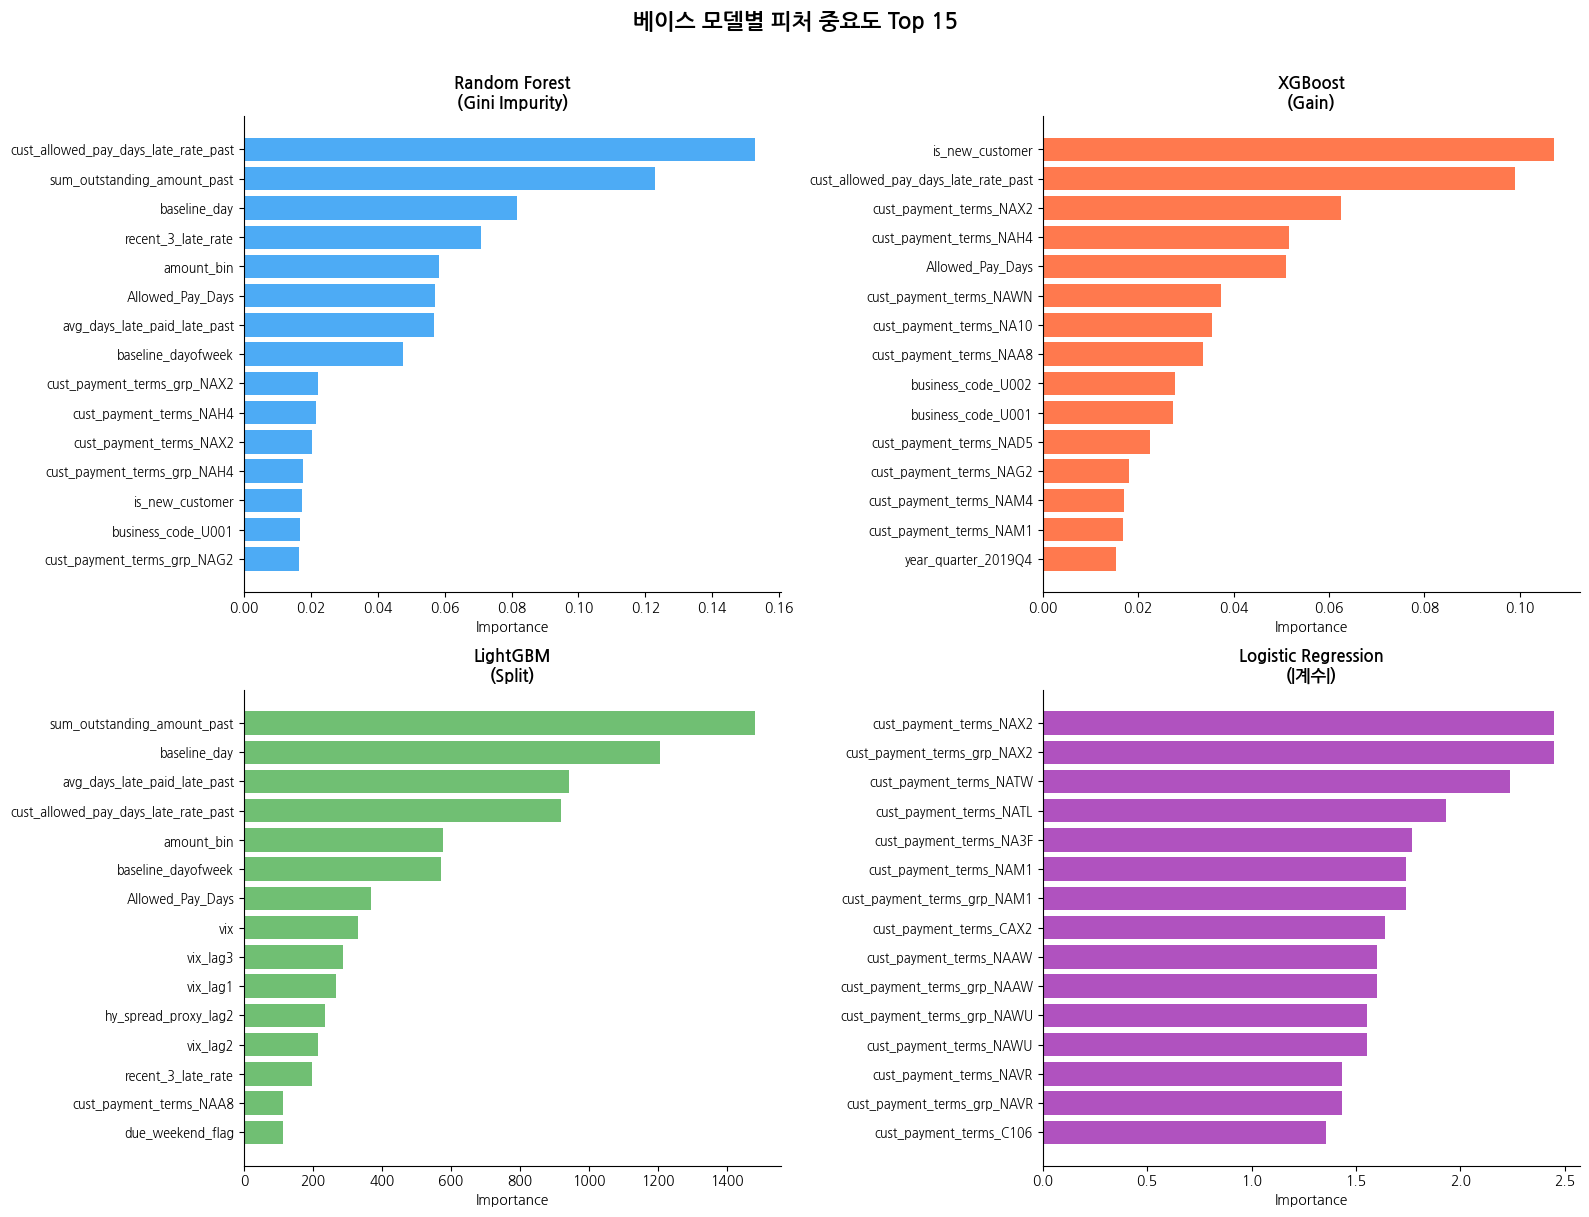

저장: feature_importance_by_model.png


In [ ]:
TOP_N = 15

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('베이스 모델별 피처 중요도 Top 15', fontsize=16, fontweight='bold', y=1.01)

plot_data = [
    ("Random Forest\n(Gini Impurity)", rf_importance, "#2196F3"),
    ("XGBoost\n(Gain)", xgb_importance, "#FF5722"),
    ("LightGBM\n(Split)", lgbm_importance, "#4CAF50"),
    ("Logistic Regression\n(|계수|)", lr_importance, "#9C27B0"),
]

for ax, (title, importance, color) in zip(axes.flatten(), plot_data):
    top = importance.head(TOP_N)
    ax.barh(range(TOP_N), top.values[::-1], color=color, alpha=0.8)
    ax.set_yticks(range(TOP_N))
    ax.set_yticklabels(top.index[::-1], fontsize=9)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel("Importance")
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('feature_importance_by_model.png', dpi=150, bbox_inches='tight')
plt.show()
print("저장: feature_importance_by_model.png")

메타 모델 계수 (양수=연체 기여, 음수=정상 기여)
  LR (로지스틱 회귀)              +3.1435  ▲ 연체 기여
  RF (랜덤 포레스트)              +3.0105  ▲ 연체 기여
  XGB (XGBoost)             +0.0374  ▲ 연체 기여
  LGBM (LightGBM)           +1.4985  ▲ 연체 기여


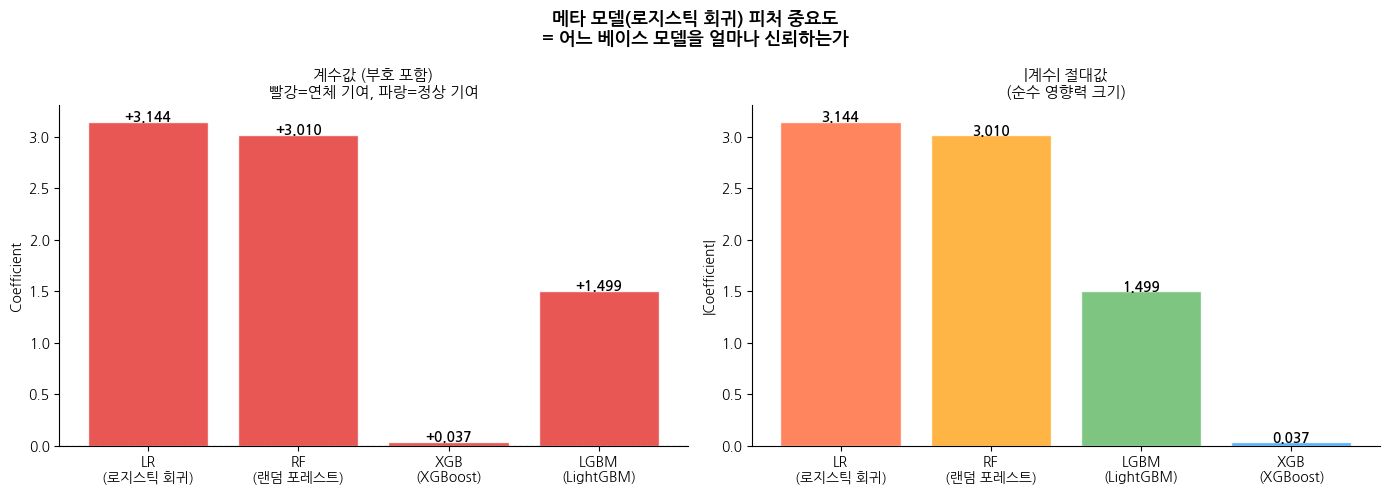

저장: meta_model_feature_importance.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 메타 모델 계수 추출
# meta_model의 입력: [LR_prob, RF_prob, XGB_prob, LGBM_prob]
meta_feature_names = ['LR\n(로지스틱 회귀)', 'RF\n(랜덤 포레스트)', 'XGB\n(XGBoost)', 'LGBM\n(LightGBM)']
meta_coef = meta_model.coef_[0]  # shape: (4,)

meta_importance = pd.Series(meta_coef, index=meta_feature_names)
meta_importance_sorted = meta_importance.abs().sort_values(ascending=False)

print("=" * 45)
print("메타 모델 계수 (양수=연체 기여, 음수=정상 기여)")
print("=" * 45)
for name, coef in zip(meta_feature_names, meta_coef):
    direction = "▲ 연체 기여" if coef > 0 else "▼ 정상 기여"
    print(f"  {name.replace(chr(10), ' '):<25} {coef:+.4f}  {direction}")

# ── 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('메타 모델(로지스틱 회귀) 피처 중요도\n= 어느 베이스 모델을 얼마나 신뢰하는가',
             fontsize=13, fontweight='bold')

# 왼쪽: 원래 계수값 (부호 포함 → 방향성 파악)
colors = ['#E53935' if c > 0 else '#1E88E5' for c in meta_coef]
axes[0].bar(meta_feature_names, meta_coef, color=colors, alpha=0.85, edgecolor='white')
axes[0].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('계수값 (부호 포함)\n빨강=연체 기여, 파랑=정상 기여', fontsize=11)
axes[0].set_ylabel('Coefficient')
axes[0].spines[['top', 'right']].set_visible(False)
for i, v in enumerate(meta_coef):
    axes[0].text(i, v + 0.01 * np.sign(v), f'{v:+.3f}', ha='center', fontsize=10, fontweight='bold')

# 오른쪽: 절대값 (순수 영향력 크기)
imp_sorted_idx = np.argsort(np.abs(meta_coef))[::-1]
sorted_names = [meta_feature_names[i] for i in imp_sorted_idx]
sorted_abs   = np.abs(meta_coef)[imp_sorted_idx]
bar_colors   = ['#FF7043', '#FFA726', '#66BB6A', '#42A5F5']

axes[1].bar(sorted_names, sorted_abs, color=bar_colors, alpha=0.85, edgecolor='white')
axes[1].set_title('|계수| 절대값\n(순수 영향력 크기)', fontsize=11)
axes[1].set_ylabel('|Coefficient|')
axes[1].spines[['top', 'right']].set_visible(False)
for i, v in enumerate(sorted_abs):
    axes[1].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('meta_model_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("저장: meta_model_feature_importance.png")

In [ ]:
from sklearn.metrics import precision_recall_curve, roc_curve, roc_auc_score, f1_score

# 최종 예측 확률 (앞서 구한 final_pred_prob 사용)
thresholds = np.arange(0.1, 0.9, 0.01)

results = []
for t in thresholds:
    pred_t = (final_pred_prob >= t).astype(int)
    results.append({
        'threshold' : round(t, 2),
        'accuracy'  : accuracy_score(test_y, pred_t),
        'macro_f1'  : f1_score(test_y, pred_t, average='macro'),
        'f1_class1' : f1_score(test_y, pred_t, pos_label=1, average='binary')

    })

threshold_df = pd.DataFrame(results)

# 목적에 따라 기준 선택
best_macro_f1  = threshold_df.loc[threshold_df['macro_f1'].idxmax()]
best_f1_class1 = threshold_df.loc[threshold_df['f1_class1'].idxmax()]

print("[ macro F1 최대 임계치 ]")
print(best_macro_f1.to_string())
print("\n[ 연체(class=1) F1 최대 임계치 ]")
print(best_f1_class1.to_string())

[ macro F1 최대 임계치 ]
threshold    0.390000
accuracy     0.963228
macro_f1     0.781082
f1_class1    0.581395

[ 연체(class=1) F1 최대 임계치 ]
threshold    0.390000
accuracy     0.963228
macro_f1     0.781082
f1_class1    0.581395


In [ ]:
meta_model.coef_

array([[3.14353134, 3.01049029, 0.03737798, 1.49852106]])

In [ ]:
import numpy as np

PDO     = 20
ODDS_0  = 20    # PD≈4.76% 기업이 600점 기준
SCORE_0 = 600

def prob_to_score_v1(prob):
    """본인 공식 (오즈=1일 때 600점 → 문제)"""
    prob = np.clip(prob, 1e-6, 1-1e-6)
    odds = (1 - prob) / prob
    return np.round(SCORE_0 + PDO * np.log2(odds)).astype(int)

def prob_to_score_v2(prob):
    """수정 공식 (오즈=20일 때 600점 → 올바름)"""
    prob = np.clip(prob, 1e-6, 1-1e-6)
    odds = (1 - prob) / prob
    return np.round(SCORE_0 + PDO * np.log2(odds / ODDS_0)).astype(int)

# 검증
for pd_val in [0.02, 0.05, 0.10, 0.30, 0.50]:
    print(f"PD={pd_val:.0%}  v1={prob_to_score_v1(pd_val):4d}  v2={prob_to_score_v2(pd_val):4d}")

PD=2%  v1= 712  v2= 626
PD=5%  v1= 685  v2= 599
PD=10%  v1= 663  v2= 577
PD=30%  v1= 624  v2= 538
PD=50%  v1= 600  v2= 514
